In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurazione architettura Blackwell / sm_120 per RTX serie 50
os.environ["TORCH_CUDA_ARCH_LIST"] = "12.0"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
from torch.utils.data import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix

print("CUDA disponibile:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Dispositivo rilevato:", torch.cuda.get_device_name(0))

# Download dataset
# path = kagglehub.dataset_download("priyangshumukherjee/mental-health-text-classification-dataset")

CUDA disponibile: True
Dispositivo rilevato: NVIDIA GeForce RTX 5060 Laptop GPU


In [ ]:
# Caricamento dataset 
ds_unbalanced = pd.read_csv("mental_heath_unbanlanced.csv")
ds_balanced = pd.read_csv("mental_health_combined_test.csv")
ds_feature = pd.read_csv("mental_heath_feature_engineered.csv")

# Pulizia valori nulli
ds_unbalanced['text'] = ds_unbalanced['text'].fillna('')
ds_balanced['text'] = ds_balanced['text'].fillna('')

print("Distribuzione Training Set sbilanciato:")
print(ds_unbalanced['status'].value_counts())
print("\nDistribuzione Test Set bilanciato:")
print(ds_balanced['status'].value_counts())

Distribuzione Training Set sbilanciato:
status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

Distribuzione Test Set bilanciato:
status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64


C:\Users\miche\AppData\Local\Temp\ipykernel_22612\942247321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ds_unbalanced, x='status', order=ds_unbalanced['status'].value_counts().index, palette='Blues_r')


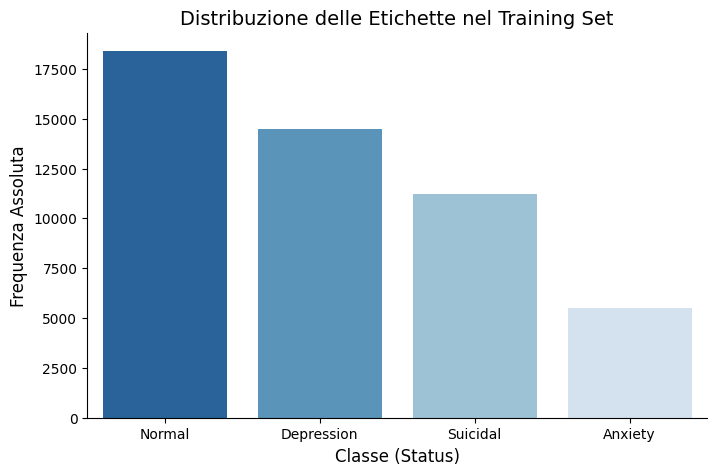

C:\Users\miche\AppData\Local\Temp\ipykernel_22612\942247321.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ds_unbalanced, x='status', y='text_length', palette='Set2')


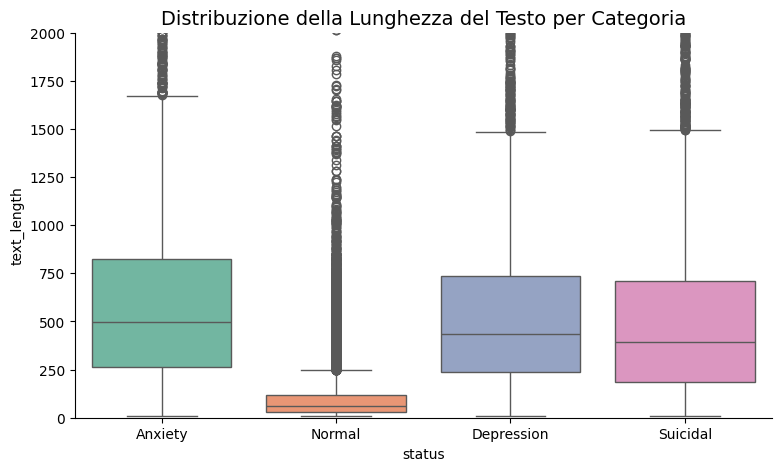

C:\Users\miche\AppData\Local\Temp\ipykernel_22612\942247321.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ds_feature, x='status', y='num_excess_punct', palette='magma', errorbar=None)


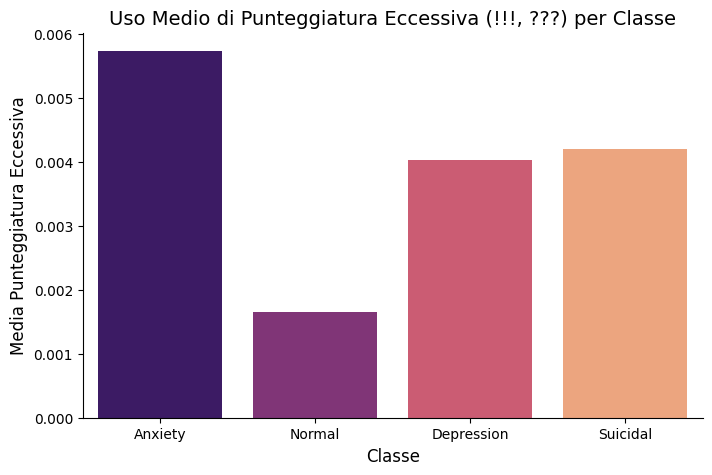

In [ ]:
# 1. Grafico Distribuzione Classi (Sbilanciamento)
plt.figure(figsize=(8, 5))
sns.countplot(data=ds_unbalanced, x='status', order=ds_unbalanced['status'].value_counts().index, palette='Blues_r')
plt.title('Distribuzione delle Etichette nel Training Set', fontsize=14)
plt.xlabel('Classe (Status)', fontsize=12)
plt.ylabel('Frequenza Assoluta', fontsize=12)
sns.despine()
plt.show()

# 2. Analisi Lunghezza dei Testi
ds_unbalanced['text_length'] = ds_unbalanced['text'].astype(str).apply(len)

plt.figure(figsize=(9, 5))
sns.boxplot(data=ds_unbalanced, x='status', y='text_length', palette='Set2')
plt.title('Distribuzione della Lunghezza del Testo per Categoria', fontsize=14)
plt.ylim(0, 2000)
sns.despine()
plt.show()

# 3. Analisi Punteggiatura Eccessiva da kaggle
plt.figure(figsize=(8, 5))
sns.barplot(data=ds_feature, x='status', y='num_excess_punct', palette='magma', errorbar=None)
plt.title('Uso Medio di Punteggiatura Eccessiva (!!!, ???) per Classe', fontsize=14)
plt.ylabel('Media Punteggiatura Eccessiva', fontsize=12)
plt.xlabel('Classe', fontsize=12)
sns.despine()
plt.show()

In [ ]:
# Split 80/20 rigoroso sul dataset sbilanciato usato per i vari modelli
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    ds_unbalanced['text'],
    ds_unbalanced['status'],
    test_size=0.2,
    random_state=42,
    stratify=ds_unbalanced['status']
)

# Test Set Ufficiale Bilanciato intatto (992 campioni, 248 per classe)
X_test_eval = ds_balanced['text']
y_test_eval = ds_balanced['status']

print(f"Campioni effettivi di Training:   {len(X_train_raw)}")
print(f"Campioni effettivi di Validation: {len(X_val_raw)}")
print(f"Campioni Test Set Bilanciato:     {len(X_test_eval)}")

Campioni effettivi di Training:   39689
Campioni effettivi di Validation: 9923
Campioni Test Set Bilanciato:     992


=== BASELINE: TF-IDF + LOGISTIC REGRESSION (TEST SET BILANCIATO) ===
              precision    recall  f1-score   support

     Anxiety       0.79      0.77      0.78       248
  Depression       0.59      0.58      0.58       248
      Normal       0.79      0.83      0.81       248
    Suicidal       0.71      0.71      0.71       248

    accuracy                           0.72       992
   macro avg       0.72      0.72      0.72       992
weighted avg       0.72      0.72      0.72       992



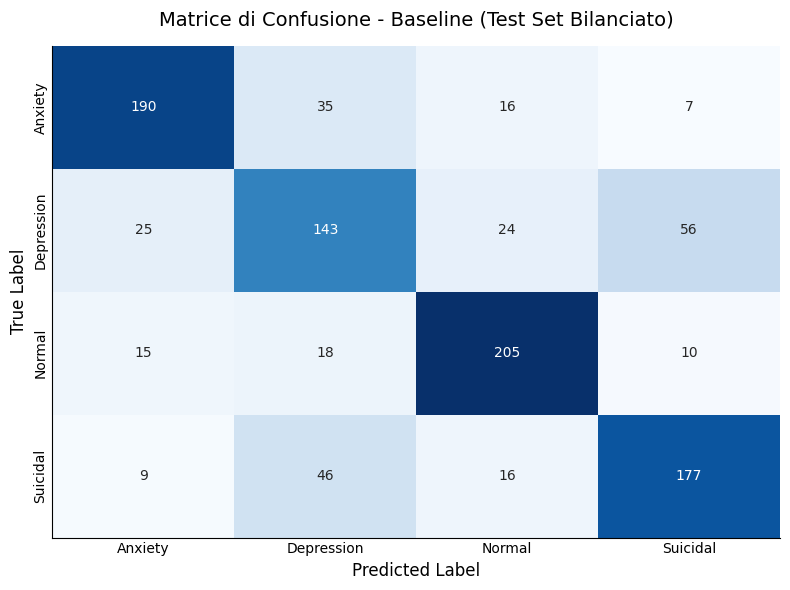

In [ ]:
# TF-IDF limitato a 5000 feature 
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf = tfidf.transform(X_val_raw)
X_test_tfidf = tfidf.transform(X_test_eval)

#  Addestramento con pesi bilanciati
clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train_raw)

# Report su Test Set Bilanciato
y_pred_baseline = clf.predict(X_test_tfidf)
print("=== BASELINE: TF-IDF + LOGISTIC REGRESSION (TEST SET BILANCIATO) ===")
print(classification_report(y_test_eval, y_pred_baseline))

#  Matrice di Confusione Baseline
classes_order = ['Anxiety', 'Depression', 'Normal', 'Suicidal']
cm_baseline = confusion_matrix(y_test_eval, y_pred_baseline, labels=classes_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=classes_order, yticklabels=classes_order, cbar=False)
plt.title('Matrice di Confusione - Baseline (Test Set Bilanciato)', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tick_params(axis='both', which='both', length=0)
sns.despine()
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=100)
plt.show()

In [6]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

label_mapping = {
    'Normal': 0,
    'Depression': 1,
    'Anxiety': 2,
    'Suicidal': 3
}

class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.map(label_mapping).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = MentalHealthDataset(X_train_raw, y_train_raw, tokenizer, max_length=128)
val_dataset = MentalHealthDataset(X_val_raw, y_val_raw, tokenizer, max_length=128)
test_dataset = MentalHealthDataset(X_test_eval, y_test_eval, tokenizer, max_length=128)

print(f"Dataset RoBERTa pronti. Dimensione Training: {len(train_dataset)}")

Dataset RoBERTa pronti. Dimensione Training: 39689


In [7]:
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=4)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

training_args = TrainingArguments(
    output_dir='./roberta_output',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
    dataloader_pin_memory=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Avvio del training (circa 2480 step totali)
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.367409,0.339166,0.861332,0.852807,0.852874,0.853677
2,0.272313,0.326964,0.868890,0.860408,0.858428,0.863685


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2482, training_loss=0.3749024478011704, metrics={'train_runtime': 1948.863, 'train_samples_per_second': 40.73, 'train_steps_per_second': 1.274, 'total_flos': 5221401098115072.0, 'train_loss': 0.3749024478011704, 'epoch': 2.0})

 CONFRONTO FINALE: ROBERTA (TEST SET BILANCIATO)
              precision    recall  f1-score   support

     Anxiety       0.86      0.85      0.86       248
  Depression       0.82      0.87      0.84       248
      Normal       0.98      0.94      0.96       248
    Suicidal       0.98      0.98      0.98       248

    accuracy                           0.91       992
   macro avg       0.91      0.91      0.91       992
weighted avg       0.91      0.91      0.91       992



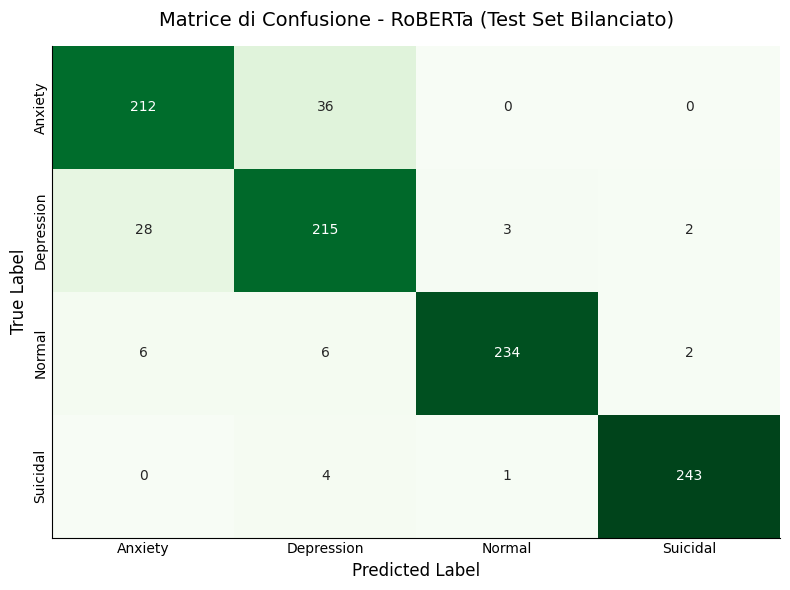

In [9]:
predictions = trainer.predict(test_dataset)
y_pred_roberta_idx = np.argmax(predictions.predictions, axis=1)

id_to_label = {v: k for k, v in label_mapping.items()}
y_true_final = [id_to_label[idx] for idx in predictions.label_ids]
y_pred_final = [id_to_label[idx] for idx in y_pred_roberta_idx]

print(" CONFRONTO FINALE: ROBERTA (TEST SET BILANCIATO)")
print(classification_report(y_true_final, y_pred_final))

# Matrice di confusione RoBERTa
cm_roberta = confusion_matrix(y_true_final, y_pred_final, labels=classes_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Greens', xticklabels=classes_order, yticklabels=classes_order, cbar=False)
plt.title('Matrice di Confusione - RoBERTa (Test Set Bilanciato)', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tick_params(axis='both', which='both', length=0)
sns.despine()
plt.tight_layout()
plt.savefig('confusion_matrix_roberta.png', dpi=100)
plt.show()